In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [3]:
df = pd.read_csv(r"D:\git\python-data-analysis-lab\datasets\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df[df['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


<Axes: >

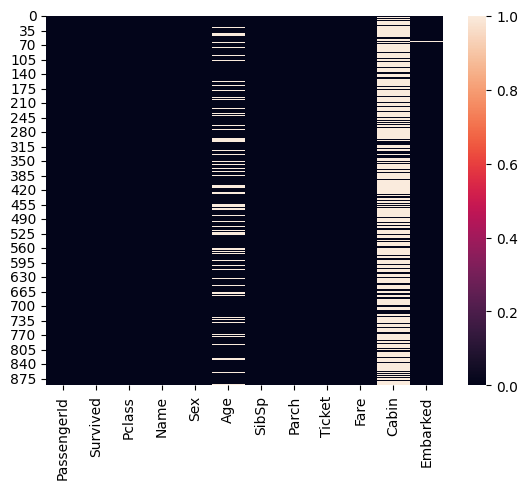

In [7]:
sns.heatmap(df.isnull())

In [8]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [10]:
df[df['Ticket']=="113572" ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [ ]:
df['Embarked'].mode() # shosw the highest value "S" has higher count

0    S
Name: Embarked, dtype: object

In [14]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [16]:
df['Embarked'].mode()[0]

'S'

In [17]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace =True)

In [19]:
df.drop("Cabin",inplace=True,axis =1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [22]:
df['Age'].mean()

np.float64(29.69911764705882)

In [26]:
df.groupby("Pclass")['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [27]:
df.loc[df['Pclass']==3,'Age'] = df.loc[df['Pclass']==3,'Age'].fillna(38)
df.loc[df['Pclass']==2,'Age'] = df.loc[df['Pclass']==2,'Age'].fillna(29)
df.loc[df['Pclass']==1,'Age'] = df.loc[df['Pclass']==1,'Age'].fillna(25)

In [28]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [30]:
df.drop(['PassengerId',"Name","Ticket"], inplace= True, axis =1)

In [31]:
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C


In [32]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['Sex', 'Embarked'], dtype='object')

In [34]:
num_cols = df.select_dtypes(['int','float'])
num_cols

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,38.0,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [35]:
from sklearn.preprocessing import OrdinalEncoder

In [36]:
oe = OrdinalEncoder()

In [37]:
df[cat_cols]= oe.fit_transform(df[cat_cols])

In [38]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1.0,22.0,1,0,7.2500,2.0
1,1,1,0.0,38.0,1,0,71.2833,0.0
2,1,3,0.0,26.0,0,0,7.9250,2.0
3,1,1,0.0,35.0,1,0,53.1000,2.0
4,0,3,1.0,35.0,0,0,8.0500,2.0


In [40]:
df[['Age','SibSp','Parch','Fare']].describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,30.799293,0.523008,0.381594,32.204208
std,13.383582,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,30.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


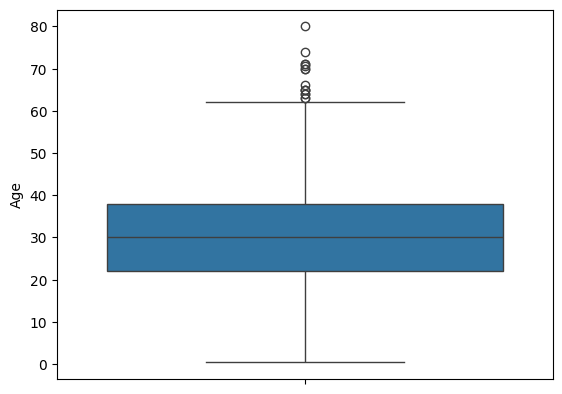

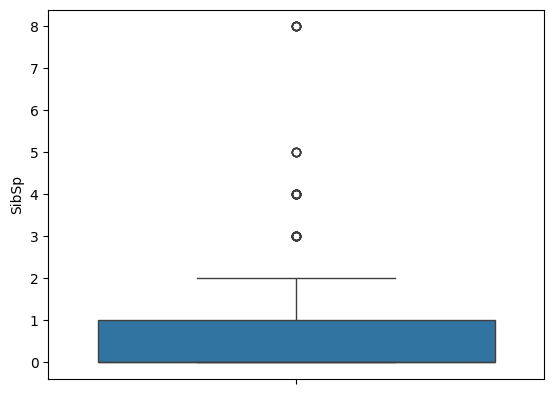

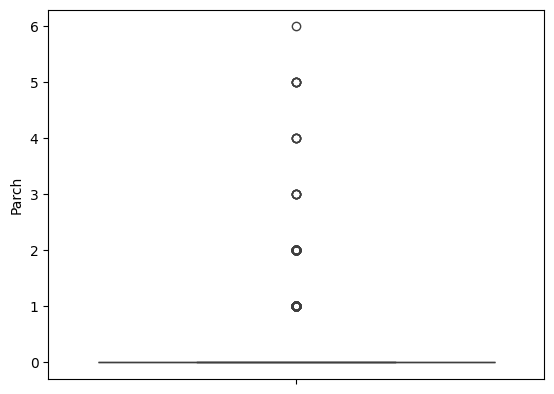

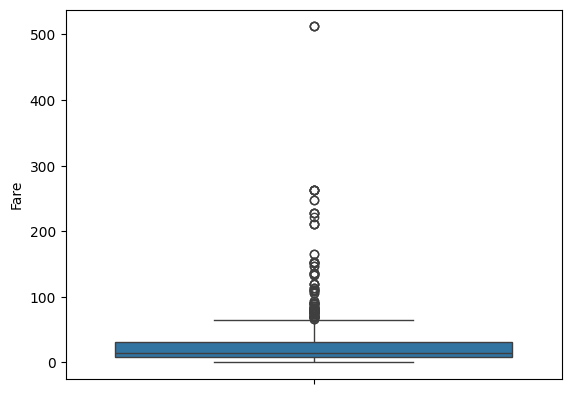

In [41]:
for col in df[['Age','SibSp','Parch','Fare']]:
    sns.boxplot(df[col])
    plt.show()

In [42]:
df[['Age','SibSp','Parch','Fare']].skew()

Age      0.185730
SibSp    3.695352
Parch    2.749117
Fare     4.787317
dtype: float64

col:  0.18573037220693403


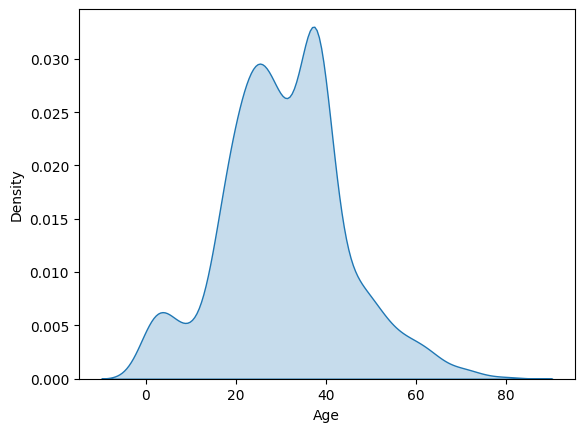

col:  3.6953517271630565


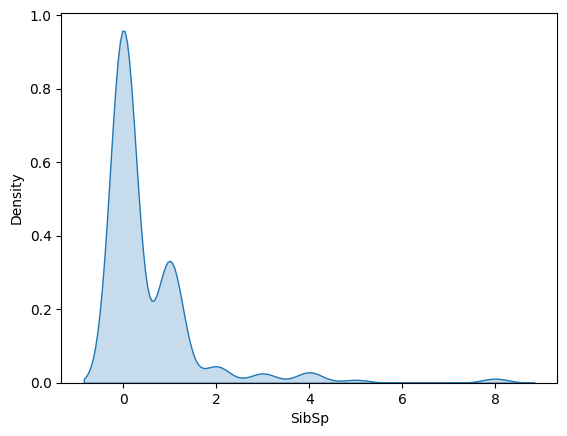

col:  2.7491170471010933


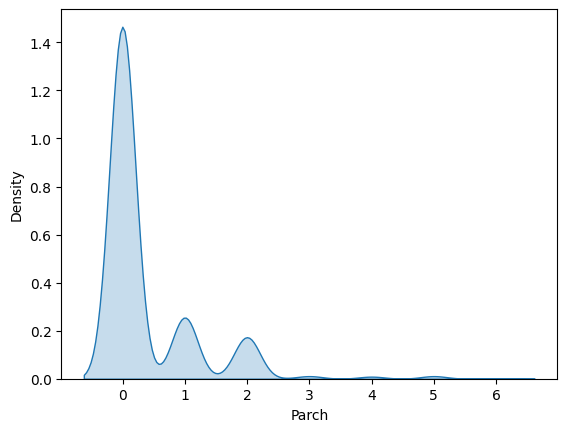

col:  4.787316519674893


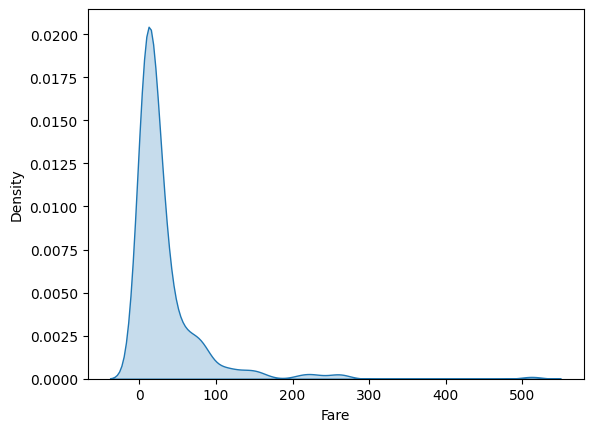

In [46]:
cols = df[['Age','SibSp','Parch','Fare']]
for col in cols:
    skewness = df[col].skew()
    print("col: ",skewness)
    sns.kdeplot(df[col], fill=True)
    plt.show()

In [48]:
df['FamilySize'] = df['Parch'] + df['SibSp']+1

In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,1.0,22.0,1,0,7.2500,2.0,2
1,1,1,0.0,38.0,1,0,71.2833,0.0,2
2,1,3,0.0,26.0,0,0,7.9250,2.0,1
3,1,1,0.0,35.0,1,0,53.1000,2.0,2
4,0,3,1.0,35.0,0,0,8.0500,2.0,1


In [56]:
import numpy as np

df['isAlone'] = np.where(df['FamilySize'] == 1,1,0)

In [57]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,isAlone
0,0,3,1.0,22.0,1,0,7.2500,2.0,2,0
1,1,1,0.0,38.0,1,0,71.2833,0.0,2,0
2,1,3,0.0,26.0,0,0,7.9250,2.0,1,1
3,1,1,0.0,35.0,1,0,53.1000,2.0,2,0
4,0,3,1.0,35.0,0,0,8.0500,2.0,1,1


In [58]:
df.drop(['SibSp','Parch'], inplace = True, axis=1)

In [59]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,isAlone
0,0,3,1.0,22.0,7.2500,2.0,2,0
1,1,1,0.0,38.0,71.2833,0.0,2,0
2,1,3,0.0,26.0,7.9250,2.0,1,1
3,1,1,0.0,35.0,53.1000,2.0,2,0
4,0,3,1.0,35.0,8.0500,2.0,1,1


In [61]:
x= df.drop("Survived",axis=1)
y=df['Survived']

In [64]:
x.head(), y.head()

(   Pclass  Sex   Age     Fare  Embarked  FamilySize  isAlone
 0       3  1.0  22.0   7.2500       2.0           2        0
 1       1  0.0  38.0  71.2833       0.0           2        0
 2       3  0.0  26.0   7.9250       2.0           1        1
 3       1  0.0  35.0  53.1000       2.0           2        0
 4       3  1.0  35.0   8.0500       2.0           1        1,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [65]:
xtrain,xtest, ytrain,ytest= train_test_split(x,y,test_size=0.3,random_state=42)

In [66]:
len(xtrain), len(ytrain), len(xtest),len(ytest)

(623, 623, 268, 268)

In [67]:
xtrain.shape

(623, 7)

In [68]:
xtest.shape

(268, 7)

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [70]:
dt = DecisionTreeClassifier(random_state =42)

In [71]:
# For now we use default parameters.

# Meaning:

# max_depth = None
# min_samples_split = 2

In [72]:
dt.fit(xtrain,ytrain)

DecisionTreeClassifier(random_state=42)

In [73]:
ypred = dt.predict(xtest)
ypred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0])

In [74]:
ytest

709    1
439    0
840    0
720    1
39     1
      ..
821    1
633    0
456    0
500    0
430    1
Name: Survived, Length: 268, dtype: int64

In [75]:
accuracy = accuracy_score(ytest,ypred)
accuracy

0.753731343283582

In [77]:
cm = confusion_matrix(ytest,ypred)
cm

array([[127,  30],
       [ 36,  75]])

In [80]:
from sklearn.metrics import classification_report

print(
    classification_report(
        ytest,
        ypred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       157
           1       0.71      0.68      0.69       111

    accuracy                           0.75       268
   macro avg       0.75      0.74      0.74       268
weighted avg       0.75      0.75      0.75       268



In [85]:
# Preciosn : Out of all people we predicted survived, how many actually survived?
# recall: Out of all actual survivors, how many did we find? or out of ho wmuch died we failed to find as dead

In [86]:
depth_values = [2,3,4,5,6,7,8,10,None]

train_scores = []
test_scores = []

for depth in depth_values:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(
        xtrain,
        ytrain
    )

    train_score = dt.score(
        xtrain,
        ytrain
    )

    test_score = dt.score(
        xtest,
        ytest
    )

    train_scores.append(train_score)
    test_scores.append(test_score)

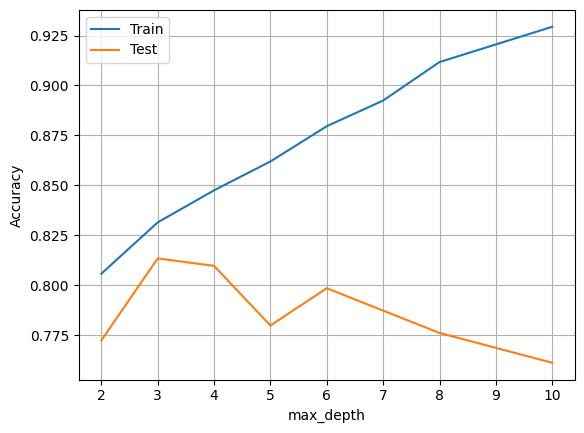

In [87]:
plt.plot(depth_values, train_scores, label="Train")
plt.plot(depth_values, test_scores, label="Test")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

In [89]:
split_values = [2,5,10,20,30,50]

train_scores=[]
test_scores=[]


for split in split_values:

    dt = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=split,
        random_state=42
    )

    dt.fit(
        xtrain,
        ytrain
    )

    train_scores.append(
        dt.score(xtrain,ytrain)
    )

    test_scores.append(
        dt.score(xtest,ytest)
    )

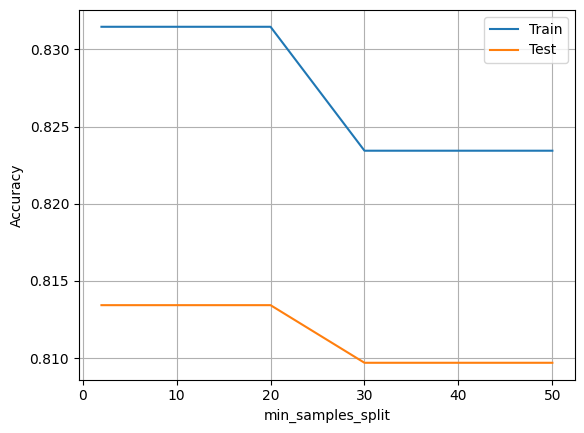

In [90]:
plt.plot(split_values,train_scores,label="Train")
plt.plot(split_values,test_scores,label="Test")

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

In [91]:
dt_best = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    random_state=42
)

In [92]:
dt_best.fit(
    xtrain,
    ytrain
)

DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42)

In [93]:
dt_pred = dt_best.predict(xtest)

In [96]:
best_accuracy=accuracy_score(ytest, ypred)
print(best_accuracy)

cr = classification_report(
    ytest,
    dt_pred
)
cr

0.753731343283582


'              precision    recall  f1-score   support\n\n           0       0.81      0.89      0.85       157\n           1       0.82      0.70      0.76       111\n\n    accuracy                           0.81       268\n   macro avg       0.82      0.80      0.80       268\nweighted avg       0.81      0.81      0.81       268\n'

In [97]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [98]:
rf = RandomForestClassifier(random_state=42)

In [99]:
# By default:
# n_estimators = 100

# Meaning:
# 100 Decision Trees

In [100]:
rf.fit(xtrain,ytrain)

RandomForestClassifier(random_state=42)

In [101]:
rf_pred = rf.predict(xtest)
rf_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0])

In [102]:
ytest

709    1
439    0
840    0
720    1
39     1
      ..
821    1
633    0
456    0
500    0
430    1
Name: Survived, Length: 268, dtype: int64

In [104]:
ac = accuracy_score(
    ytest,
    rf_pred
)
ac

0.7798507462686567

In [106]:
cm = confusion_matrix(
    ytest,
    rf_pred
)

cm

array([[129,  28],
       [ 31,  80]])

In [107]:
from sklearn.metrics import classification_report

print(
    classification_report(
        ytest,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       157
           1       0.74      0.72      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



In [108]:
# Step 7: ROC-AUC
# Remember:
# For ROC-AUC we need probability.

In [109]:
rf_prob = rf.predict_proba(xtest)[:,1]

In [110]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    ytest,
    rf_prob
)

np.float64(0.8697997360417743)

In [112]:
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy":[
        accuracy_score(ytest,dt_pred),
        accuracy_score(ytest,rf_pred)
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.813433
1,Random Forest,0.779851


In [ ]:
#Tune Estimators
estimators = [10,50,100,150,200,300]

train_scores=[]
test_scores=[]


for n in estimators:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    rf.fit(
        xtrain,
        ytrain
    )

    train_scores.append(
        rf.score(xtrain,ytrain)
    )

    test_scores.append(
        rf.score(xtest,ytest)
    )

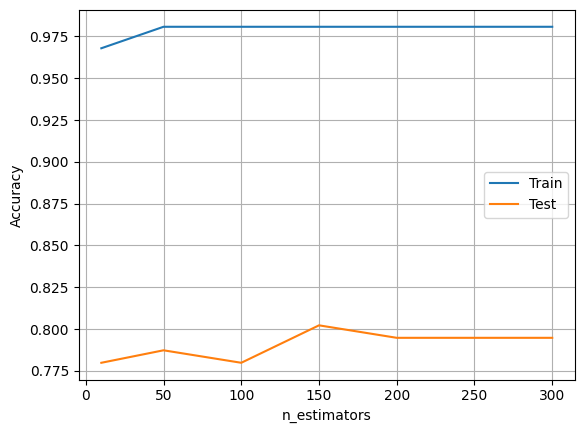

In [114]:
plt.plot(
    estimators,
    train_scores,
    label="Train"
)

plt.plot(
    estimators,
    test_scores,
    label="Test"
)

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

In [115]:
#Tune Max_depth

In [116]:
depths=[2,3,4,5,6,8,10,None]


train_scores=[]
test_scores=[]


for depth in depths:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )

    rf.fit(
        xtrain,
        ytrain
    )

    train_scores.append(
        rf.score(xtrain,ytrain)
    )

    test_scores.append(
        rf.score(xtest,ytest)
    )

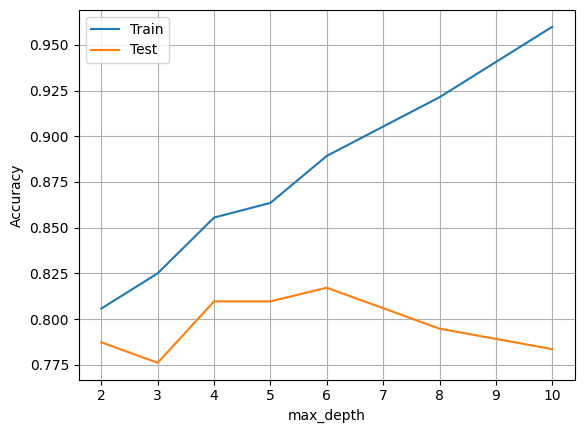

In [117]:
plt.plot(depths,train_scores,label="Train")
plt.plot(depths,test_scores,label="Test")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

In [118]:
# Tune min_samples_split

In [119]:
splits=[2,5,10,20,30,50]


train_scores=[]
test_scores=[]


for split in splits:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=split,
        random_state=42
    )

    rf.fit(
        xtrain,
        ytrain
    )


    train_scores.append(
        rf.score(xtrain,ytrain)
    )


    test_scores.append(
        rf.score(xtest,ytest)
    )

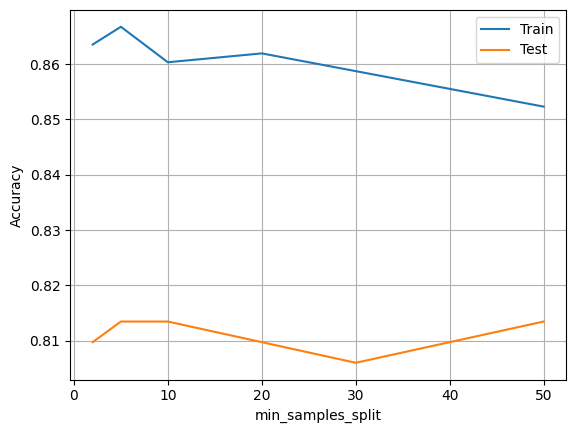

In [123]:
plt.plot(
    splits,
    train_scores,
    label="Train"
)

plt.plot(
    splits,
    test_scores,
    label="Test"
)

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

In [120]:
# 4: Tune max_features

In [121]:
features=[
    "sqrt",
    "log2",
    None
]

In [122]:
for feature in features:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        max_features=feature,
        random_state=42
    )

    rf.fit(
        xtrain,
        ytrain
    )

    pred = rf.predict(xtest)

    print(
        feature,
        accuracy_score(
            ytest,
            pred
        )
    )

sqrt 0.8134328358208955
log2 0.8134328358208955
None 0.7985074626865671


In [124]:
best_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

In [125]:
best_rf.fit(
    xtrain,
    ytrain
)

RandomForestClassifier(max_depth=6, min_samples_split=5, n_estimators=150,
                       random_state=42)

In [126]:
best_pred = best_rf.predict(xtest)

In [127]:
accuracy_score(
    ytest,
    best_pred
)

0.7985074626865671

In [128]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    ytest,
    best_pred
)

cm

array([[140,  17],
       [ 37,  74]])

In [129]:
from sklearn.metrics import classification_report

print(
    classification_report(
        ytest,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       157
           1       0.81      0.67      0.73       111

    accuracy                           0.80       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.80      0.79       268



In [130]:
best_prob = best_rf.predict_proba(xtest)[:,1]

In [131]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    ytest,
    best_prob
)

np.float64(0.886239742927641)

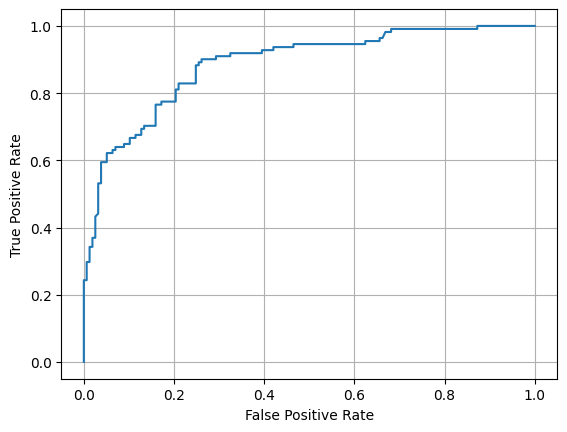

In [132]:
from sklearn.metrics import roc_curve

fpr,tpr,thresholds = roc_curve(
    ytest,
    best_prob
)


plt.plot(
    fpr,
    tpr
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid()
plt.show()